# MobileNetV2 3-Class Image Classification with Keras

This notebook trains a 3-class classifier using `MobileNetV2` transfer learning with a configurable `alpha` width multiplier.

In [ ]:
from pathlib import Path
from typing import List
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print('TensorFlow:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.10.0
GPU available: True


In [ ]:
SEED = 42
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 16
HEAD_EPOCHS = 10
FINETUNE_EPOCHS = 10
ALPHA = 0.35
CLASS_NAMES = ['Amine', 'Rifki', 'Jakub']
DATA_ROOT = Path('../data')
MODEL_PATH = Path('saved_model/mobilenetv2_3class_classifier.keras')

keras.utils.set_random_seed(SEED)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Could not find dataset directory: {DATA_ROOT.resolve()}')

print('Data root:', DATA_ROOT.resolve())
print('Alpha:', ALPHA)

Data root: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\data
Alpha: 0.35


In [ ]:
def collect_split_dataframe(data_root: Path, class_names: List[str], split: str) -> pd.DataFrame:
    records = []
    valid_ext = {'.png', '.jpg', '.jpeg', '.bmp'}

    for class_name in class_names:
        split_dir = data_root / class_name / split
        if not split_dir.exists():
            raise FileNotFoundError(f'Missing split directory: {split_dir}')

        for file_path in sorted(split_dir.iterdir()):
            if file_path.is_file() and file_path.suffix.lower() in valid_ext:
                records.append({'filepath': str(file_path), 'label': class_name})

    if not records:
        raise ValueError(f'No images found for split={split!r}')

    df = pd.DataFrame(records)
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


train_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'train')
test_df = collect_split_dataframe(DATA_ROOT, CLASS_NAMES, 'test')

display(train_df.head())
print('Train samples:', len(train_df))
print(train_df['label'].value_counts().sort_index())
print()
print('Test samples:', len(test_df))
print(test_df['label'].value_counts().sort_index())

,filepath,label
0,..\data\Jakub\train\image_20260314_150704.png,Jakub
1,..\data\Amine\train\image_20260321_204014_brig...,Amine
2,..\data\Jakub\train\image_20260314_145634_comp...,Jakub
3,..\data\Rifki\train\image_20260312_074749_occl...,Rifki
4,..\data\Rifki\train\image_20260305_130142_hfli...,Rifki


Train samples: 2160
label
Amine    720
Jakub    720
Rifki    720
Name: count, dtype: int64

Test samples: 540
label
Amine    180
Jakub    180
Rifki    180
Name: count, dtype: int64


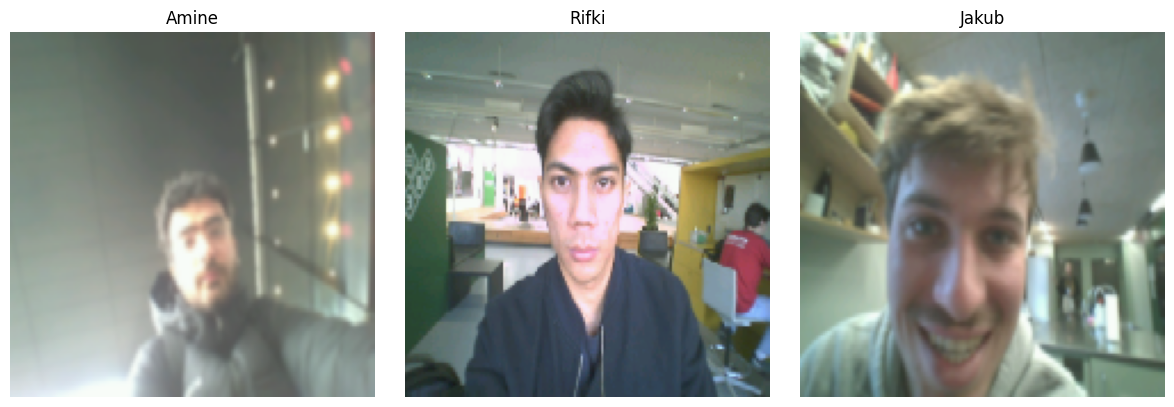

In [ ]:
sample_paths = []
for class_name in CLASS_NAMES:
    class_rows = train_df[train_df['label'] == class_name]
    sample_paths.append(class_rows.sample(1, random_state=SEED).iloc[0]['filepath'])

plt.figure(figsize=(12, 4))
for i, image_path in enumerate(sample_paths, start=1):
    image = keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    plt.subplot(1, len(sample_paths), i)
    plt.imshow(image)
    plt.title(Path(image_path).parts[-3])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=12,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
)

test_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='training',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True,
)

val_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='validation',
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print('Class indices:', train_gen.class_indices)

Found 1728 validated image filenames belonging to 3 classes.
Found 432 validated image filenames belonging to 3 classes.
Found 540 validated image filenames belonging to 3 classes.
Class indices: {'Amine': 0, 'Rifki': 1, 'Jakub': 2}


In [ ]:
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=IMAGE_SIZE + (3,),
    alpha=ALPHA,
)
base_model.trainable = False

inputs = keras.Input(shape=IMAGE_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)

model = keras.Model(inputs, outputs, name='MobileNetV2_3Class')
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy'],
)


model.summary()

Model: "MobileNetV2_3Class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 mobilenetv2_0.35_160 (Funct  (None, 5, 5, 1280)       410208    
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               163968    
                                                                 
 dropout_3 (Dropout)         (None, 128)        

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True),
]

history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)

Epoch 1/10
108/108 [==============================] - 14s 111ms/step - loss: 0.5531 - accuracy: 0.8750 - val_loss: 0.3782 - val_accuracy: 0.9838 - lr: 0.0010
Epoch 2/10
108/108 [==============================] - 11s 100ms/step - loss: 0.3947 - accuracy: 0.9751 - val_loss: 0.3421 - val_accuracy: 0.9977 - lr: 0.0010
Epoch 3/10
108/108 [==============================] - 10s 94ms/step - loss: 0.3756 - accuracy: 0.9826 - val_loss: 0.3352 - val_accuracy: 0.9931 - lr: 0.0010
Epoch 4/10
108/108 [==============================] - 11s 106ms/step - loss: 0.3559 - accuracy: 0.9925 - val_loss: 0.3353 - val_accuracy: 0.9907 - lr: 0.0010
Epoch 5/10
108/108 [==============================] - 11s 103ms/step - loss: 0.3531 - accuracy: 0.9884 - val_loss: 0.3306 - val_accuracy: 0.9931 - lr: 0.0010
Epoch 6/10
108/108 [==============================] - 11s 104ms/step - loss: 0.3465 - accuracy: 0.9931 - val_loss: 0.3273 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 7/10
108/108 [==============================] -

In [ ]:
base_model = model.layers[1]
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=FINETUNE_EPOCHS,
    callbacks=callbacks,
)

model = keras.models.load_model(MODEL_PATH)

Epoch 1/10
108/108 [==============================] - 14s 112ms/step - loss: 0.1067 - accuracy: 0.9959 - val_loss: 0.0825 - val_accuracy: 0.9954 - lr: 1.0000e-06
Epoch 2/10
108/108 [==============================] - 12s 110ms/step - loss: 0.0859 - accuracy: 0.9965 - val_loss: 0.0666 - val_accuracy: 0.9977 - lr: 1.0000e-06
Epoch 3/10
108/108 [==============================] - 11s 106ms/step - loss: 0.0783 - accuracy: 0.9942 - val_loss: 0.0568 - val_accuracy: 0.9977 - lr: 1.0000e-06
Epoch 4/10
108/108 [==============================] - 20s 182ms/step - loss: 0.0674 - accuracy: 0.9971 - val_loss: 0.0544 - val_accuracy: 0.9977 - lr: 1.0000e-06
Epoch 5/10
108/108 [==============================] - 20s 184ms/step - loss: 0.0594 - accuracy: 0.9954 - val_loss: 0.0432 - val_accuracy: 0.9977 - lr: 1.0000e-06
Epoch 6/10
108/108 [==============================] - 21s 191ms/step - loss: 0.0555 - accuracy: 0.9959 - val_loss: 0.0402 - val_accuracy: 1.0000 - lr: 1.0000e-06
Epoch 7/10
108/108 [========

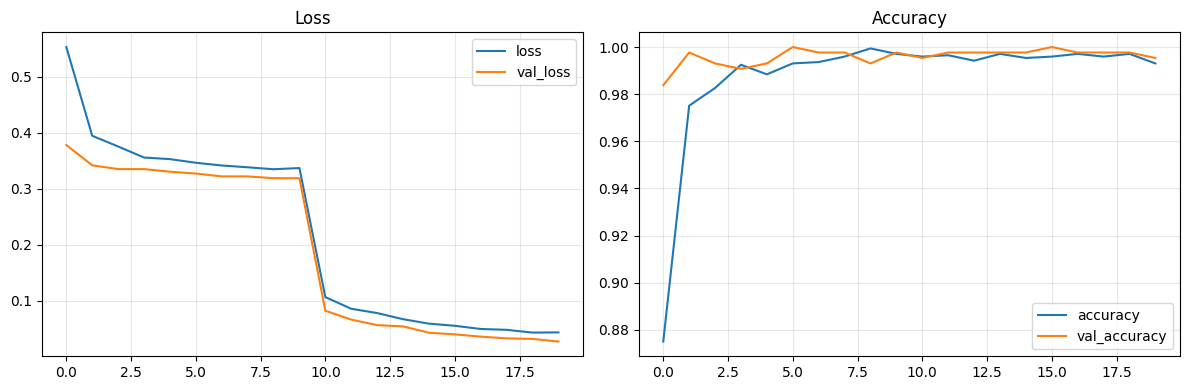

In [ ]:
history = {}
for key in history_head.history:
    history[key] = history_head.history[key] + history_finetune.history[key]

history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Test loss: 0.4097
Test accuracy: 0.9519

              precision    recall  f1-score   support

       Amine       0.89      0.98      0.93       180
       Rifki       1.00      0.99      0.99       180
       Jakub       0.98      0.89      0.93       180

    accuracy                           0.95       540
   macro avg       0.95      0.95      0.95       540
weighted avg       0.95      0.95      0.95       540



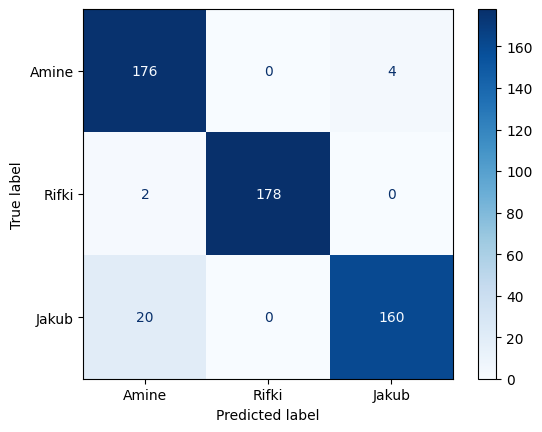

In [ ]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

probabilities = model.predict(test_gen, verbose=0)
y_pred = np.argmax(probabilities, axis=1)
y_true = test_gen.classes

print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.show()

In [ ]:
# Inference uses the full resized frame, so the notebook preview does the same.


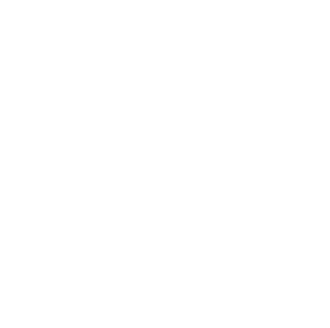

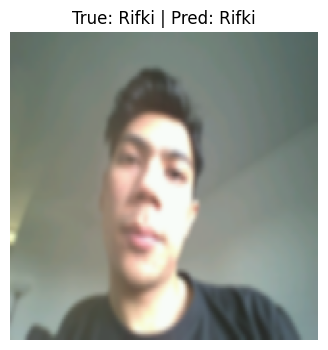

Amine: 0.0120
Rifki: 0.9790
Jakub: 0.0090

Saved model to: C:\Users\Rifki\Personal\CollegeWorkspace\HardwareSoftwareCo\Project\H-S-Codesign\python\mobilenetv2_3class_classifier.keras


In [ ]:
index_to_class = {v: k for k, v in train_gen.class_indices.items()}
random_row = test_df.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
sample_path = random_row['filepath']
plt.figure(figsize=(4, 4))
# plt.imshow(keras.utils.load_img(sample_path, target_size=IMAGE_SIZE))
plt.axis('off')
plt.show()
# sample_path = "ceiling.png"
# sample_path = "image_20260311_200130.png"

image = keras.utils.load_img(sample_path, target_size=IMAGE_SIZE)
array = keras.utils.img_to_array(image)
array = preprocess_input(array)
prediction = model.predict(np.expand_dims(array, axis=0), verbose=0)[0]
predicted_class = index_to_class[int(np.argmax(prediction))]

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.title(f'True: {random_row["label"]} | Pred: {predicted_class}')
plt.axis('off')
plt.show()

for class_name, score in zip(CLASS_NAMES, prediction):
    print(f'{class_name}: {score:.4f}')

print('\nSaved model to:', MODEL_PATH.resolve())

In [ ]:
model.summary()

Model: "MobileNetV2_3Class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 mobilenetv2_0.35_160 (Funct  (None, 5, 5, 1280)       410208    
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               163968    
                                                                 
 dropout_3 (Dropout)         (None, 128)        

## Export Deterministic Training Subset

This section saves the preprocessed training subset used by the MobileNetV2 pipeline to `saved_model/x_train.npy` and `saved_model/y_train.npy` for later quantization.

In [ ]:
VALIDATION_SPLIT = 0.2
X_TRAIN_PATH = MODEL_PATH.parent / 'x_train.npy'
Y_TRAIN_PATH = MODEL_PATH.parent / 'y_train.npy'


def make_training_subset(train_df: pd.DataFrame) -> pd.DataFrame:
    split_index = int(len(train_df) * VALIDATION_SPLIT)
    return train_df.iloc[split_index:].reset_index(drop=True)


def load_and_preprocess_images(train_subset: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    class_to_index = {name: idx for idx, name in enumerate(CLASS_NAMES)}

    x_train = []
    y_train = []

    for row in train_subset.itertuples(index=False):
        image = keras.utils.load_img(row.filepath, target_size=IMAGE_SIZE)
        array = keras.utils.img_to_array(image).astype(np.float32)
        array = preprocess_input(array)

        x_train.append(array)
        y_train.append(class_to_index[row.label])

    return np.stack(x_train).astype(np.float32), np.array(y_train, dtype=np.int32)


MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
train_subset = make_training_subset(train_df)
x_train, y_train = load_and_preprocess_images(train_subset)

np.save(X_TRAIN_PATH, x_train)
np.save(Y_TRAIN_PATH, y_train)

print(f'Saved training subset: {len(train_subset)} images')
print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'Saved: {X_TRAIN_PATH.resolve()}')
print(f'Saved: {Y_TRAIN_PATH.resolve()}')
